# Results Analysis

This notebook compares tactile, vision, and fusion detector prediction CSVs.

The workflow is:

1. Define result CSV inputs with a small `ResultCsv` object.
2. Load every CSV into a normalized pandas table.
3. Compute metrics for `all` samples and the `visuallyChallenging` subset.
4. Build headline lift, object accuracy, confidence, and error-analysis tables.
5. Render one combined confusion-matrix image per grouping/subset with all three detectors side by side.

In [36]:
from dataclasses import dataclass
from pathlib import Path
import math
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, roc_auc_score

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 200)


def displayTable(title, table):
    """Print a plain title before a dataframe so notebook outputs are easy to scan."""
    print(f"\n{title}")
    display(table)

## 1. Configure Inputs

`ResultCsv` is only used to make the input parameters explicit. Once files are loaded, analysis is done with pandas tables.

- `detectorName`: one of `vision`, `tactile`, or `fusion`.
- `csvPath`: local path or URL to a prediction CSV.
- `testSet`: source split name, such as `train`, `eval`, or `test`.
- `dataGrouping`: analysis bucket. Use `testOnly` for test-only analysis, or use `allData` on train/eval/test CSVs to combine them in memory.
- `displayName`: optional short label for this CSV in tables.

To analyze only test data, add one `ResultCsv` per detector with `testSet="test"` and `dataGrouping="testOnly"`.

To analyze the full dataset without merging files on disk, add train/eval/test CSVs for each detector with `dataGrouping="allData"`; the notebook combines them after loading.

In [37]:
@dataclass(frozen=True)
class ResultCsv:
    detectorName: str
    csvPath: str
    testSet: str
    dataGrouping: str
    displayName: str | None = None

    @staticmethod
    def slugify(value):
        """Make a short filesystem-safe label for figure filenames."""
        value = str(value).strip().lower()
        value = re.sub(r"[^a-z0-9._-]+", "_", value)
        return value.strip("_") or "unnamed"

    @staticmethod
    def normalizeBinaryLabel(series):
        """Convert common success/failure labels into 0=failure and 1=success."""
        if series.dtype == bool:
            return series.astype(int)
        mapped = series.replace({"False": 0, "True": 1, "failure": 0, "success": 1, "fail": 0, "pass": 1})
        return mapped.astype(int)

    def normalized(self):
        """Validate input metadata and fill optional display fields."""
        allowedDetectors = {"vision", "tactile", "fusion"}
        if self.detectorName not in allowedDetectors:
            raise ValueError(f"detectorName must be one of {sorted(allowedDetectors)}; got {self.detectorName!r}")
        csvStem = Path(str(self.csvPath).split("?")[0]).stem or self.detectorName
        return {
            "detectorName": self.detectorName,
            "csvPath": self.csvPath,
            "testSet": self.testSet,
            "dataGrouping": self.dataGrouping,
            "displayName": self.displayName or csvStem,
        }

    def loadPredictionTable(self):
        """Read this CSV and return the normalized columns used by the notebook."""
        source = self.normalized()
        sourceTable = pd.read_csv(source["csvPath"])
        requiredColumns = {"sample_id", "object_id", "label", "pred", "prob_success"}
        missingColumns = requiredColumns - set(sourceTable.columns)
        if missingColumns:
            raise ValueError(f"{source['csvPath']} is missing required columns: {sorted(missingColumns)}")

        predictionTable = pd.DataFrame({
            "sampleId": sourceTable["sample_id"],
            "objectId": sourceTable["object_id"],
            "trueLabel": self.normalizeBinaryLabel(sourceTable["label"]),
            "predictedLabel": self.normalizeBinaryLabel(sourceTable["pred"]),
            "probSuccess": pd.to_numeric(sourceTable["prob_success"]),
        })
        predictionTable["probFailure"] = pd.to_numeric(sourceTable["prob_failure"]) if "prob_failure" in sourceTable.columns else 1.0 - predictionTable["probSuccess"]
        predictionTable["detectorName"] = source["detectorName"]
        predictionTable["testSet"] = source["testSet"]
        predictionTable["dataGrouping"] = source["dataGrouping"]
        predictionTable["displayName"] = source["displayName"]
        predictionTable["csvPath"] = source["csvPath"]
        predictionTable["sourceRowIndex"] = np.arange(len(predictionTable))
        return predictionTable


resultCsvs = [
    # Test-only analysis: these three files are compared as one matched group.
    ResultCsv("vision", "reports/vision/vision-motion-box-cuda/test.csv", testSet="test", dataGrouping="testOnly"),
    ResultCsv("tactile", "reports/tactile/tactile-extended-cuda/test.csv", testSet="test", dataGrouping="testOnly"),
    ResultCsv("fusion", "reports/joint/joint-finetune/test.csv", testSet="test", dataGrouping="testOnly"),

    # Full-dataset analysis: keep split CSVs separate on disk, combine them in memory here.
    ResultCsv("vision", "reports/vision/vision-motion-box-cuda/train.csv", testSet="train", dataGrouping="allData"),
    ResultCsv("vision", "reports/vision/vision-motion-box-cuda/eval.csv", testSet="eval", dataGrouping="allData"),
    ResultCsv("vision", "reports/vision/vision-motion-box-cuda/test.csv", testSet="test", dataGrouping="allData"),
    ResultCsv("tactile", "reports/tactile/tactile-extended-cuda/train.csv", testSet="train", dataGrouping="allData"),
    ResultCsv("tactile", "reports/tactile/tactile-extended-cuda/eval.csv", testSet="eval", dataGrouping="allData"),
    ResultCsv("tactile", "reports/tactile/tactile-extended-cuda/test.csv", testSet="test", dataGrouping="allData"),
    ResultCsv("fusion", "reports/joint/joint-finetune/train.csv", testSet="train", dataGrouping="allData"),
    ResultCsv("fusion", "reports/joint/joint-finetune/eval.csv", testSet="eval", dataGrouping="allData"),
    ResultCsv("fusion", "reports/joint/joint-finetune/test.csv", testSet="test", dataGrouping="allData"),
]

visuallyDifficultCsv = Path("possibly-visually-difficult.csv")
# Used only by optional export lines later in the notebook.
reportDir = Path("reports/results_analysis")

## 2. Load Prediction CSVs

`rawPredictionTable` contains one row per row in the source CSVs. Column names are normalized to camel case so downstream tables are consistent.

In [38]:
if not resultCsvs:
    raise ValueError("Add at least one ResultCsv to resultCsvs before running the notebook.")

rawPredictionTable = pd.concat([resultCsv.loadPredictionTable() for resultCsv in resultCsvs], ignore_index=True)
displayTable("Raw prediction table preview", rawPredictionTable.head())
displayTable("Rows loaded from each prediction CSV", rawPredictionTable.groupby(["dataGrouping", "testSet", "detectorName", "displayName"]).size().rename("rowCount").reset_index())


Raw prediction table preview


,sampleId,objectId,trueLabel,predictedLabel,probSuccess,probFailure,detectorName,testSet,dataGrouping,displayName,csvPath,sourceRowIndex
0,000_000041_tomato_paste_in_metal_can,tomato_paste_in_metal_can,1,1,0.662807,0.337193,vision,test,testOnly,test,reports/vision/vision-motion-box-cuda/test.csv,0
1,000_000043_tomato_paste_in_metal_can,tomato_paste_in_metal_can,0,1,0.793943,0.206057,vision,test,testOnly,test,reports/vision/vision-motion-box-cuda/test.csv,1
2,000_000045_tomato_paste_in_metal_can,tomato_paste_in_metal_can,1,0,0.334191,0.665809,vision,test,testOnly,test,reports/vision/vision-motion-box-cuda/test.csv,2
3,000_000062_egg_crate_foam,egg_crate_foam,1,1,0.923273,0.076727,vision,test,testOnly,test,reports/vision/vision-motion-box-cuda/test.csv,3
4,000_000094_tomato_paste_in_metal_can,tomato_paste_in_metal_can,0,0,0.269807,0.730193,vision,test,testOnly,test,reports/vision/vision-motion-box-cuda/test.csv,4



Rows loaded from each prediction CSV


,dataGrouping,testSet,detectorName,displayName,rowCount
0,allData,eval,fusion,eval,1570
1,allData,eval,tactile,eval,1570
2,allData,eval,vision,eval,1570
3,allData,test,fusion,test,1185
4,allData,test,tactile,test,1185
5,allData,test,vision,test,1185
6,allData,train,fusion,train,6541
7,allData,train,tactile,train,6541
8,allData,train,vision,train,6541
9,testOnly,test,fusion,test,1185


## 3. Mark Visually Challenging Objects

`samplePredictionTable` contains one row per evaluated sample and detector. If the input CSV had duplicate `sampleId` rows, probabilities are averaged before metrics are computed.

In [39]:
visualObjectSourceTable = pd.read_csv(visuallyDifficultCsv)
if "object_name" not in visualObjectSourceTable.columns:
    raise ValueError(f"{visuallyDifficultCsv} must contain an object_name column")

visuallyChallengingObjects = set(visualObjectSourceTable["object_name"].dropna().astype(str))
print(f"Loaded {len(visuallyChallengingObjects)} visually challenging objects from {visuallyDifficultCsv}")


def aggregateDuplicateSamples(predictionTable):
    """Average duplicate predictions for the same detector/sample pair, such as two tactile sensors."""
    groupColumns = ["dataGrouping", "testSet", "detectorName", "displayName", "csvPath", "sampleId"]
    mostCommon = lambda s: s.mode().iloc[0] if not s.mode().empty else s.iloc[0]
    sampleTable = (
        predictionTable.groupby(groupColumns, as_index=False)
        .agg(
            objectId=("objectId", mostCommon),
            trueLabel=("trueLabel", "first"),
            probSuccess=("probSuccess", "mean"),
            probFailure=("probFailure", "mean"),
            sourceRowCount=("sourceRowIndex", "count"),
        )
    )
    # Use the standard 0.5 cutoff after probability averaging to recover hard labels.
    sampleTable["predictedLabel"] = (sampleTable["probSuccess"] >= 0.5).astype(int)
    # A split-qualified key prevents train/eval/test rows with the same sampleId from collapsing in allData analysis.
    sampleTable["sampleKey"] = sampleTable["testSet"].astype(str) + "::" + sampleTable["sampleId"].astype(str)
    return sampleTable


samplePredictionTable = aggregateDuplicateSamples(rawPredictionTable)
samplePredictionTable["isVisuallyChallenging"] = samplePredictionTable["objectId"].isin(visuallyChallengingObjects)

displayTable("Loaded sample counts by detector", samplePredictionTable.groupby(["dataGrouping", "detectorName"]).agg(sampleCount=("sampleKey", "nunique"), rowCount=("sampleKey", "size")).reset_index())
displayTable("Visually challenging sample counts by detector", samplePredictionTable.groupby(["dataGrouping", "detectorName"])["isVisuallyChallenging"].agg(visuallyChallengingSamples="sum", visuallyChallengingFraction="mean").reset_index())

# Optional export:
# samplePredictionTable.to_csv(reportDir / "samplePredictionTable.csv", index=False)

Loaded 35 visually challenging objects from possibly-visually-difficult.csv

Loaded sample counts by detector


,dataGrouping,detectorName,sampleCount,rowCount
0,allData,fusion,9296,9296
1,allData,tactile,9296,9296
2,allData,vision,9296,9296
3,testOnly,fusion,1185,1185
4,testOnly,tactile,1185,1185
5,testOnly,vision,1185,1185



Visually challenging sample counts by detector


,dataGrouping,detectorName,visuallyChallengingSamples,visuallyChallengingFraction
0,allData,fusion,2353,0.253120
1,allData,tactile,2353,0.253120
2,allData,vision,2353,0.253120
3,testOnly,fusion,99,0.083544
4,testOnly,tactile,99,0.083544
5,testOnly,vision,99,0.083544


## 4. Build Analysis Subsets

`analysisPredictionTable` duplicates rows into analysis subsets. Every sample appears in `all`; visually challenging samples also appear in `visuallyChallenging`.

In [40]:
allSampleSubset = samplePredictionTable.assign(analysisSubset="all")
visuallyChallengingSubset = samplePredictionTable[samplePredictionTable["isVisuallyChallenging"]].assign(analysisSubset="visuallyChallenging")
analysisPredictionTable = pd.concat([allSampleSubset, visuallyChallengingSubset], ignore_index=True)

displayTable("Analysis subsets by split and detector", analysisPredictionTable.groupby(["dataGrouping", "testSet", "analysisSubset", "detectorName"])["sampleKey"].nunique().rename("sampleCount").reset_index())

# Optional export:
# analysisPredictionTable.to_csv(reportDir / "analysisPredictionTable.csv", index=False)


Analysis subsets by split and detector


,dataGrouping,testSet,analysisSubset,detectorName,sampleCount
0,allData,eval,all,fusion,1570
1,allData,eval,all,tactile,1570
2,allData,eval,all,vision,1570
3,allData,eval,visuallyChallenging,fusion,483
4,allData,eval,visuallyChallenging,tactile,483
5,allData,eval,visuallyChallenging,vision,483
6,allData,test,all,fusion,1185
7,allData,test,all,tactile,1185
8,allData,test,all,vision,1185
9,allData,test,visuallyChallenging,fusion,99


## 5. Check Detector Alignment

`alignmentTable` checks that detectors in the same data grouping are evaluated on matching sample IDs.

In [41]:
alignmentRows = []
for (dataGrouping, analysisSubset), groupedTable in analysisPredictionTable.groupby(["dataGrouping", "analysisSubset"]):
    sampleSetsByDetector = {detectorName: set(detectorTable["sampleKey"]) for detectorName, detectorTable in groupedTable.groupby("detectorName")}
    sampleUnion = set().union(*sampleSetsByDetector.values()) if sampleSetsByDetector else set()
    sampleIntersection = set.intersection(*sampleSetsByDetector.values()) if sampleSetsByDetector else set()
    for detectorName, sampleIds in sampleSetsByDetector.items():
        alignmentRows.append({
            "dataGrouping": dataGrouping,
            "analysisSubset": analysisSubset,
            "detectorName": detectorName,
            "sampleCount": len(sampleIds),
            "missingFromDetector": len(sampleUnion - sampleIds),
            "extraVsIntersection": len(sampleIds - sampleIntersection),
            "intersectionSize": len(sampleIntersection),
            "unionSize": len(sampleUnion),
        })

alignmentTable = pd.DataFrame(alignmentRows)
displayTable("Detector sample alignment by data grouping", alignmentTable)


Detector sample alignment by data grouping


,dataGrouping,analysisSubset,detectorName,sampleCount,missingFromDetector,extraVsIntersection,intersectionSize,unionSize
0,allData,all,fusion,9296,0,0,9296,9296
1,allData,all,tactile,9296,0,0,9296,9296
2,allData,all,vision,9296,0,0,9296,9296
3,allData,visuallyChallenging,fusion,2353,0,0,2353,2353
4,allData,visuallyChallenging,tactile,2353,0,0,2353,2353
5,allData,visuallyChallenging,vision,2353,0,0,2353,2353
6,testOnly,all,fusion,1185,0,0,1185,1185
7,testOnly,all,tactile,1185,0,0,1185,1185
8,testOnly,all,vision,1185,0,0,1185,1185
9,testOnly,visuallyChallenging,fusion,99,0,0,99,99


## 6. Compute Metrics

`metricsTable` contains the core deliverable metrics: accuracy, macro F1, binary AUROC, and confusion-matrix counts.

In [42]:
def safeAuroc(trueLabels, successScores):
    """AUROC is undefined when a subset contains only one ground-truth class."""
    if len(pd.Series(trueLabels).dropna().unique()) < 2:
        return np.nan
    return roc_auc_score(trueLabels, successScores)


def computeMetrics(groupedTable):
    """Compute binary classification metrics for one detector and one analysis subset."""
    trueLabels = groupedTable["trueLabel"].astype(int).to_numpy()
    predictedLabels = groupedTable["predictedLabel"].astype(int).to_numpy()
    successScores = groupedTable["probSuccess"].astype(float).to_numpy()
    matrix = confusion_matrix(trueLabels, predictedLabels, labels=[0, 1])
    auroc = safeAuroc(trueLabels, successScores)
    return {
        "dataGrouping": groupedTable["dataGrouping"].iloc[0],
        "testSet": "+".join(sorted(groupedTable["testSet"].astype(str).unique())),
        "analysisSubset": groupedTable["analysisSubset"].iloc[0],
        "detectorName": groupedTable["detectorName"].iloc[0],
        "displayName": "+".join(sorted(groupedTable["displayName"].astype(str).unique())),
        "sampleCount": int(len(groupedTable)),
        "successCount": int((trueLabels == 1).sum()),
        "failureCount": int((trueLabels == 0).sum()),
        "accuracy": float(accuracy_score(trueLabels, predictedLabels)),
        "macroF1": float(f1_score(trueLabels, predictedLabels, average="macro", labels=[0, 1], zero_division=0)),
        "auroc": float(auroc) if not math.isnan(auroc) else np.nan,
        "trueFailurePredFailure": int(matrix[0, 0]),
        "trueFailurePredSuccess": int(matrix[0, 1]),
        "trueSuccessPredFailure": int(matrix[1, 0]),
        "trueSuccessPredSuccess": int(matrix[1, 1]),
        "confusionMatrix": matrix,
    }


metricRows = []
for _, groupedTable in analysisPredictionTable.groupby(["dataGrouping", "analysisSubset", "detectorName"], sort=True):
    metricRows.append(computeMetrics(groupedTable))

metricsTable = pd.DataFrame(metricRows).sort_values(["dataGrouping", "analysisSubset", "detectorName"])
displayTable("Metrics by detector and analysis subset", metricsTable.drop(columns=["confusionMatrix"]))

# Optional export:
# metricsTable.drop(columns=["confusionMatrix"]).to_csv(reportDir / "metricsTable.csv", index=False)


Metrics by detector and analysis subset


,dataGrouping,testSet,analysisSubset,detectorName,displayName,sampleCount,successCount,failureCount,accuracy,macroF1,auroc,trueFailurePredFailure,trueFailurePredSuccess,trueSuccessPredFailure,trueSuccessPredSuccess
0,allData,eval+test+train,all,fusion,eval+test+train,9296,5969,3327,0.881562,0.870499,0.940071,2739,588,513,5456
1,allData,eval+test+train,all,tactile,eval+test+train,9296,5969,3327,0.854131,0.836586,0.926938,2447,880,476,5493
2,allData,eval+test+train,all,vision,eval+test+train,9296,5969,3327,0.778077,0.756572,0.828462,2235,1092,971,4998
3,allData,eval+test+train,visuallyChallenging,fusion,eval+test+train,2353,1553,800,0.899278,0.887407,0.951747,676,124,113,1440
4,allData,eval+test+train,visuallyChallenging,tactile,eval+test+train,2353,1553,800,0.881853,0.866103,0.946905,634,166,112,1441
5,allData,eval+test+train,visuallyChallenging,vision,eval+test+train,2353,1553,800,0.806205,0.784224,0.869856,573,227,229,1324
6,testOnly,test,all,fusion,test,1185,854,331,0.832068,0.799105,0.877633,253,78,121,733
7,testOnly,test,all,tactile,test,1185,854,331,0.881857,0.855384,0.933729,269,62,78,776
8,testOnly,test,all,vision,test,1185,854,331,0.747679,0.673102,0.689168,160,171,128,726
9,testOnly,test,visuallyChallenging,fusion,test,99,87,12,0.858586,0.751435,0.886973,10,2,12,75


## 7. Combined Confusion Matrices

Each figure shows vision, tactile, and fusion together for one `dataGrouping` and `analysisSubset`.

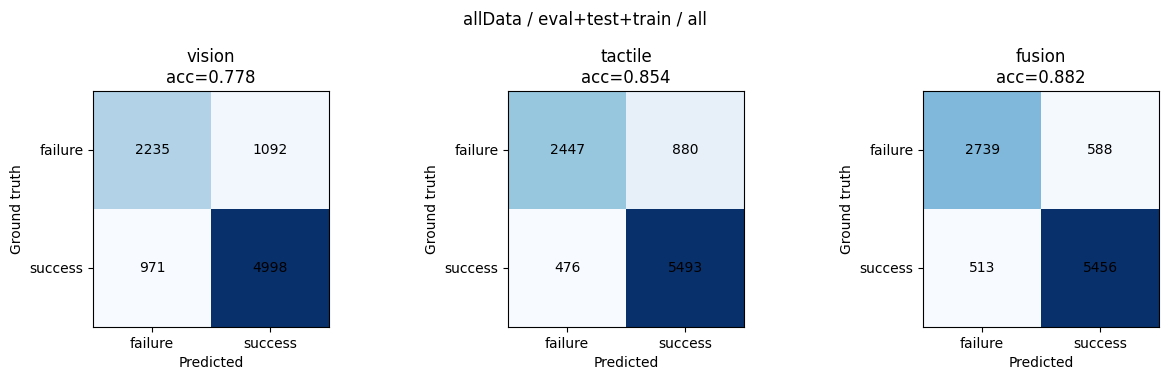

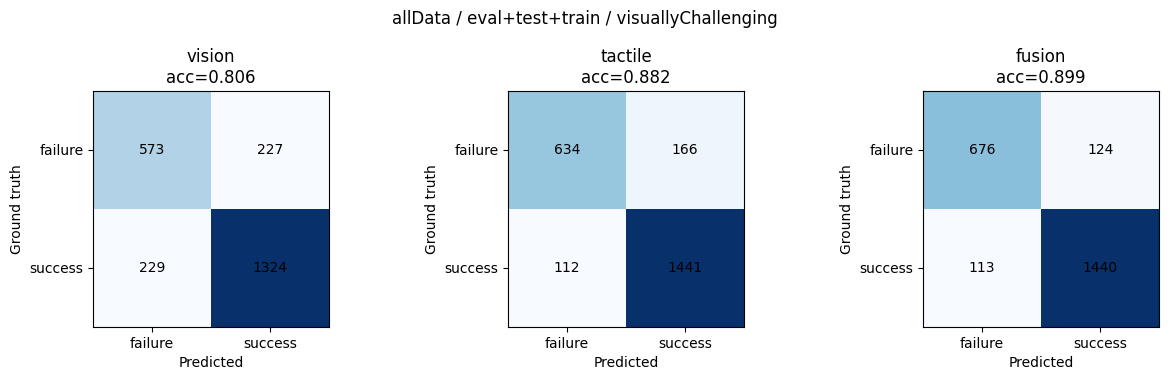

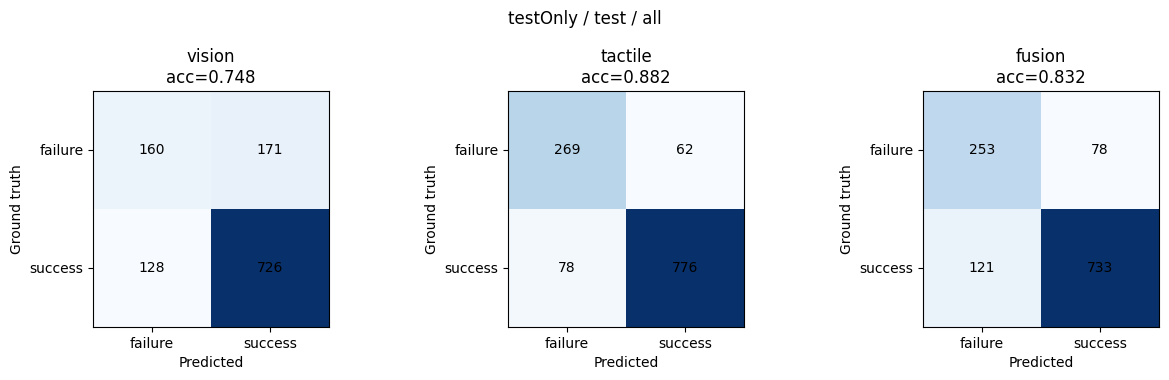

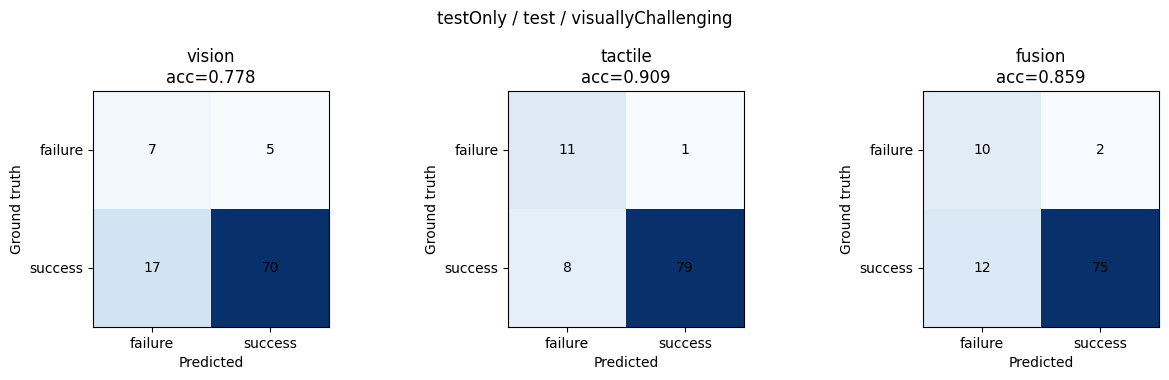

In [ ]:
def drawConfusionMatrix(axis, matrix, title):
    """Draw one small confusion matrix on an existing matplotlib axis."""
    # Display order matches the metric code: 0=failure and 1=success.
    labelNames = ["failure", "success"]
    axis.imshow(matrix, cmap="Blues")
    axis.set_title(title)
    axis.set_xticks([0, 1], labelNames)
    axis.set_yticks([0, 1], labelNames)
    axis.set_xlabel("Predicted")
    axis.set_ylabel("Ground truth")
    for rowIndex in range(2):
        for columnIndex in range(2):
            axis.text(columnIndex, rowIndex, str(int(matrix[rowIndex, columnIndex])), ha="center", va="center", color="black")


detectorOrder = ["vision", "tactile", "fusion"]
for (dataGrouping, testSet, analysisSubset), matrixGroup in metricsTable.groupby(["dataGrouping", "testSet", "analysisSubset"]):
    figure, axes = plt.subplots(1, len(detectorOrder), figsize=(4.2 * len(detectorOrder), 3.8), squeeze=False)
    for axis, detectorName in zip(axes[0], detectorOrder):
        detectorRows = matrixGroup[matrixGroup["detectorName"].eq(detectorName)]
        if detectorRows.empty:
            axis.axis("off")
            axis.set_title(f"{detectorName}\nmissing")
            continue
        metricRow = detectorRows.iloc[0]
        title = f"{detectorName}\nacc={metricRow['accuracy']:.3f}"
        drawConfusionMatrix(axis, metricRow["confusionMatrix"], title)
    figure.suptitle(f"{dataGrouping} / {testSet} / {analysisSubset}")
    figure.tight_layout()
    Optional figure export:
    (reportDir / "confusion_matrices").mkdir(parents=True, exist_ok=True)
    figurePath = reportDir / "confusion_matrices" / f"{ResultCsv.slugify(dataGrouping)}_{ResultCsv.slugify(testSet)}_{ResultCsv.slugify(analysisSubset)}_confusion_matrices.png"
    figure.savefig(figurePath, dpi=180)
    plt.show()
    plt.close(figure)

## 8. Headline Lift Table

`headlineResultsTable` compares detector accuracy within each grouping and computes tactile/fusion lift over vision.

In [44]:
accuracyWideTable = metricsTable.pivot_table(index=["dataGrouping", "testSet", "analysisSubset"], columns="detectorName", values="accuracy", aggfunc="first")
sampleCountTable = metricsTable.groupby(["dataGrouping", "testSet", "analysisSubset"])["sampleCount"].min().rename("sampleCount")
headlineResultsTable = accuracyWideTable.rename(columns={"vision": "visionAccuracy", "tactile": "tactileAccuracy", "fusion": "fusionAccuracy"}).join(sampleCountTable)
if {"tactileAccuracy", "visionAccuracy"}.issubset(headlineResultsTable.columns):
    headlineResultsTable["tactileLift"] = headlineResultsTable["tactileAccuracy"] - headlineResultsTable["visionAccuracy"]
if {"fusionAccuracy", "visionAccuracy"}.issubset(headlineResultsTable.columns):
    headlineResultsTable["fusionLift"] = headlineResultsTable["fusionAccuracy"] - headlineResultsTable["visionAccuracy"]
headlineResultsTable = headlineResultsTable.reset_index()
headlineResultsTable.insert(0, "labelName", "graspOutcome")
displayTable("Headline accuracy and lift table", headlineResultsTable)

# Optional export:
# headlineResultsTable.to_csv(reportDir / "headlineResultsTable.csv", index=False)


Headline accuracy and lift table


,labelName,dataGrouping,testSet,analysisSubset,fusionAccuracy,tactileAccuracy,visionAccuracy,sampleCount,tactileLift,fusionLift
0,graspOutcome,allData,eval+test+train,all,0.881562,0.854131,0.778077,9296,0.076054,0.103485
1,graspOutcome,allData,eval+test+train,visuallyChallenging,0.899278,0.881853,0.806205,2353,0.075648,0.093073
2,graspOutcome,testOnly,test,all,0.832068,0.881857,0.747679,1185,0.134177,0.084388
3,graspOutcome,testOnly,test,visuallyChallenging,0.858586,0.909091,0.777778,99,0.131313,0.080808


## 9. Object Accuracy Table

`objectAccuracyTable` shows which detector has the highest accuracy for each object.

In [45]:
objectAccuracyLongTable = (
    samplePredictionTable.assign(isCorrect=lambda table: table["trueLabel"].eq(table["predictedLabel"]))
    .groupby(["dataGrouping", "objectId", "isVisuallyChallenging", "detectorName"], as_index=False)
    .agg(sampleCount=("sampleKey", "nunique"), accuracy=("isCorrect", "mean"))
)

objectAccuracyTable = objectAccuracyLongTable.pivot_table(
    index=["dataGrouping", "objectId", "isVisuallyChallenging"], columns="detectorName", values="accuracy", aggfunc="first"
).reset_index()

detectorColumns = [column for column in detectorOrder if column in objectAccuracyTable.columns]


def bestDetectorNames(row, columns):
    """Return all detector names tied for the best value in a row."""
    values = row[columns].dropna()
    if values.empty:
        return np.nan
    bestValue = values.max()
    return ",".join(values[values == bestValue].index.tolist())


objectAccuracyTable["bestDetectorByAccuracy"] = objectAccuracyTable.apply(lambda row: bestDetectorNames(row, detectorColumns), axis=1)
objectSampleCountTable = samplePredictionTable.groupby(["dataGrouping", "objectId"])["sampleKey"].nunique().rename("sampleCount").reset_index()
objectAccuracyTable = objectSampleCountTable.merge(objectAccuracyTable, on=["dataGrouping", "objectId"], how="right")
displayTable("Object accuracy by detector", objectAccuracyTable.sort_values(["dataGrouping", "isVisuallyChallenging", "bestDetectorByAccuracy", "objectId"]))

# Optional export:
# objectAccuracyTable.to_csv(reportDir / "objectAccuracyTable.csv", index=False)


Object accuracy by detector


,dataGrouping,objectId,sampleCount,isVisuallyChallenging,fusion,tactile,vision,bestDetectorByAccuracy
1,allData,3d_printed_blue_connector,72,False,0.930556,0.902778,0.777778,fusion
2,allData,3d_printed_blue_house,40,False,0.875000,0.850000,0.800000,fusion
5,allData,angry_bird,40,False,0.750000,0.700000,0.600000,fusion
6,allData,aspirin,709,False,0.851904,0.849083,0.765867,fusion
9,allData,bag_pack,38,False,0.921053,0.868421,0.842105,fusion
18,allData,brown_paper_cup_2_upside,350,False,1.000000,0.997143,0.988571,fusion
21,allData,chocolate_shake,63,False,0.873016,0.793651,0.761905,fusion
28,allData,dog_toy_ice_cream_cone,240,False,0.854167,0.762500,0.729167,fusion
33,allData,fake_flower_in_pot,73,False,0.917808,0.835616,0.849315,fusion
35,allData,feathered_ball,12,False,0.916667,0.750000,0.333333,fusion


## 10. Correct-Prediction Confidence Table

`objectConfidenceTable` averages the probability assigned to the true class, but only on correct predictions.

In [46]:
confidenceSourceTable = samplePredictionTable.copy()
confidenceSourceTable["isCorrect"] = confidenceSourceTable["trueLabel"].eq(confidenceSourceTable["predictedLabel"])
confidenceSourceTable["trueClassProbability"] = np.where(
    # Success is class 1, so use probSuccess when the true label is success.
    confidenceSourceTable["trueLabel"].eq(1),
    confidenceSourceTable["probSuccess"],
    confidenceSourceTable["probFailure"],
)

objectConfidenceLongTable = (
    confidenceSourceTable[confidenceSourceTable["isCorrect"]]
    .groupby(["dataGrouping", "objectId", "isVisuallyChallenging", "detectorName"], as_index=False)
    .agg(correctSampleCount=("sampleKey", "nunique"), meanCorrectConfidence=("trueClassProbability", "mean"))
)

objectConfidenceTable = objectConfidenceLongTable.pivot_table(
    index=["dataGrouping", "objectId", "isVisuallyChallenging"],
    columns="detectorName",
    values="meanCorrectConfidence",
    aggfunc="first",
).reset_index()

confidenceDetectorColumns = [column for column in detectorOrder if column in objectConfidenceTable.columns]
objectConfidenceTable["bestDetectorByCorrectConfidence"] = objectConfidenceTable.apply(lambda row: bestDetectorNames(row, confidenceDetectorColumns), axis=1)
objectConfidenceTable = objectSampleCountTable.merge(objectConfidenceTable, on=["dataGrouping", "objectId"], how="right")
displayTable("Object confidence on correct predictions", objectConfidenceTable.sort_values(["dataGrouping", "isVisuallyChallenging", "bestDetectorByCorrectConfidence", "objectId"]))

# Optional export:
# objectConfidenceTable.to_csv(reportDir / "objectConfidenceTable.csv", index=False)


Object confidence on correct predictions


,dataGrouping,objectId,sampleCount,isVisuallyChallenging,fusion,tactile,vision,bestDetectorByCorrectConfidence
3,allData,3d_printed_blue_vase,58,False,0.952976,0.902965,0.771472,fusion
8,allData,baby_cup,54,False,0.957281,0.940180,0.846054,fusion
9,allData,bag_pack,38,False,0.957503,0.910778,0.682840,fusion
10,allData,bandaid_box,60,False,0.930356,0.862431,0.729761,fusion
11,allData,black_beans_bag,31,False,0.970117,0.811172,0.887365,fusion
17,allData,brown_paper_cup,6,False,0.980708,0.855273,0.880829,fusion
18,allData,brown_paper_cup_2_upside,350,False,0.996954,0.956539,0.975931,fusion
19,allData,calcium_antacid,16,False,0.920672,0.880604,0.688851,fusion
21,allData,chocolate_shake,63,False,0.906593,0.884480,0.684822,fusion
23,allData,coffee_cup,7,False,0.978108,0.894320,0.801013,fusion


## 11. Error Slices For The Writeup

`widePredictionTable` puts detector predictions for the same sample on one row so we can find where one modality catches another modality's mistake.

In [47]:
widePredictionTable = samplePredictionTable.pivot_table(
    index=["dataGrouping", "testSet", "sampleKey", "sampleId", "objectId", "isVisuallyChallenging", "trueLabel"],
    columns="detectorName",
    values=["predictedLabel", "probSuccess"],
    aggfunc="first",
)
widePredictionTable.columns = [f"{valueName}_{detectorName}" for valueName, detectorName in widePredictionTable.columns]
widePredictionTable = widePredictionTable.reset_index()

for detectorName in detectorOrder:
    predictionColumn = f"predictedLabel_{detectorName}"
    if predictionColumn in widePredictionTable.columns:
        widePredictionTable[f"isCorrect_{detectorName}"] = widePredictionTable[predictionColumn].eq(widePredictionTable["trueLabel"])

errorSliceDenominatorTable = widePredictionTable.groupby(["dataGrouping", "isVisuallyChallenging", "objectId"])["sampleKey"].nunique().rename("sampleCount").reset_index()


def addObjectRate(errorSliceTable, countColumn):
    """Add per-object sample counts and a rate so large objects do not dominate by count alone."""
    rateColumn = countColumn + "Rate"
    errorSliceTable = errorSliceDenominatorTable.merge(errorSliceTable, on=["dataGrouping", "isVisuallyChallenging", "objectId"], how="left")
    errorSliceTable[countColumn] = errorSliceTable[countColumn].fillna(0).astype(int)
    errorSliceTable[rateColumn] = errorSliceTable[countColumn] / errorSliceTable["sampleCount"]
    return errorSliceTable.sort_values(["dataGrouping", rateColumn, countColumn, "objectId"], ascending=[True, False, False, True])

if {"isCorrect_vision", "isCorrect_tactile"}.issubset(widePredictionTable.columns):
    tactileCatchesVisionTable = (
        widePredictionTable[(~widePredictionTable["isCorrect_vision"]) & (widePredictionTable["isCorrect_tactile"])]
        .groupby(["dataGrouping", "isVisuallyChallenging", "objectId"])
        .size()
        .rename("visionWrongTactileCorrect")
        .reset_index()
    )
    tactileCatchesVisionTable = addObjectRate(tactileCatchesVisionTable, "visionWrongTactileCorrect")
    displayTable("Objects where vision is wrong and tactile is correct", tactileCatchesVisionTable[tactileCatchesVisionTable["visionWrongTactileCorrect"] > 0].head(30))

if {"isCorrect_vision", "isCorrect_fusion"}.issubset(widePredictionTable.columns):
    fusionCatchesVisionTable = (
        widePredictionTable[(~widePredictionTable["isCorrect_vision"]) & (widePredictionTable["isCorrect_fusion"])]
        .groupby(["dataGrouping", "isVisuallyChallenging", "objectId"])
        .size()
        .rename("visionWrongFusionCorrect")
        .reset_index()
    )
    fusionCatchesVisionTable = addObjectRate(fusionCatchesVisionTable, "visionWrongFusionCorrect")
    displayTable("Objects where vision is wrong and fusion is correct", fusionCatchesVisionTable[fusionCatchesVisionTable["visionWrongFusionCorrect"] > 0].head(30))

visionCounterTables = []
if {"isCorrect_vision", "isCorrect_tactile"}.issubset(widePredictionTable.columns):
    table = widePredictionTable[(widePredictionTable["isCorrect_vision"]) & (~widePredictionTable["isCorrect_tactile"])].groupby(["dataGrouping", "isVisuallyChallenging", "objectId"]).size().rename("visionCorrectTactileWrong").reset_index()
    visionCounterTables.append(table)
if {"isCorrect_vision", "isCorrect_fusion"}.issubset(widePredictionTable.columns):
    table = widePredictionTable[(widePredictionTable["isCorrect_vision"]) & (~widePredictionTable["isCorrect_fusion"])].groupby(["dataGrouping", "isVisuallyChallenging", "objectId"]).size().rename("visionCorrectFusionWrong").reset_index()
    visionCounterTables.append(table)
if {"isCorrect_vision", "isCorrect_tactile", "isCorrect_fusion"}.issubset(widePredictionTable.columns):
    table = widePredictionTable[(widePredictionTable["isCorrect_vision"]) & (~widePredictionTable["isCorrect_tactile"]) & (~widePredictionTable["isCorrect_fusion"])].groupby(["dataGrouping", "isVisuallyChallenging", "objectId"]).size().rename("visionCorrectTactileAndFusionWrong").reset_index()
    visionCounterTables.append(table)

if visionCounterTables:
    visionCounterTable = objectSampleCountTable.merge(
        samplePredictionTable[["dataGrouping", "objectId", "isVisuallyChallenging"]].drop_duplicates(),
        on=["dataGrouping", "objectId"],
        how="left",
    )
    for table in visionCounterTables:
        visionCounterTable = visionCounterTable.merge(table, on=["dataGrouping", "isVisuallyChallenging", "objectId"], how="left")
    counterColumns = [column for column in visionCounterTable.columns if column.startswith("visionCorrect")]
    visionCounterTable[counterColumns] = visionCounterTable[counterColumns].fillna(0).astype(int)
    for counterColumn in counterColumns:
        visionCounterTable[counterColumn + "Rate"] = visionCounterTable[counterColumn] / visionCounterTable["sampleCount"]
    visionCounterTable["anyVisionCounterCase"] = visionCounterTable[counterColumns].sum(axis=1)
    visionCounterTable["anyVisionCounterCaseRate"] = visionCounterTable["anyVisionCounterCase"] / visionCounterTable["sampleCount"]
    visionCounterTable = visionCounterTable.sort_values(["dataGrouping", "anyVisionCounterCaseRate", "anyVisionCounterCase", "objectId"], ascending=[True, False, False, True])
    displayTable("Objects where vision is correct but tactile or fusion is wrong", visionCounterTable[visionCounterTable["anyVisionCounterCase"] > 0])

# Optional exports:
# widePredictionTable.to_csv(reportDir / "widePredictionTable.csv", index=False)
# visionCounterTable.to_csv(reportDir / "visionCounterTable.csv", index=False)


Objects where vision is wrong and tactile is correct


,dataGrouping,isVisuallyChallenging,objectId,sampleCount,visionWrongTactileCorrect,visionWrongTactileCorrectRate
76,allData,True,candle_in_glass,5,5,1.000000
21,allData,False,durabuilt_measuring_tape,10,9,0.900000
77,allData,True,dark_blue_sphere,5,4,0.800000
82,allData,True,isopropyl_alcohol,4,3,0.750000
104,allData,True,wiry_sphere,7,5,0.714286
18,allData,False,cow,10,6,0.600000
62,allData,False,sheep,5,3,0.600000
69,allData,False,yellow_wooden_robot,16,9,0.562500
41,allData,False,orange_plastic_castle,12,6,0.500000
25,allData,False,fake_plastic_transformer_toy,19,9,0.473684



Objects where vision is wrong and fusion is correct


,dataGrouping,isVisuallyChallenging,objectId,sampleCount,visionWrongFusionCorrect,visionWrongFusionCorrectRate
76,allData,True,candle_in_glass,5,5,1.000000
77,allData,True,dark_blue_sphere,5,5,1.000000
104,allData,True,wiry_sphere,7,5,0.714286
62,allData,False,sheep,5,3,0.600000
26,allData,False,feathered_ball,12,7,0.583333
21,allData,False,durabuilt_measuring_tape,10,5,0.500000
73,allData,True,black_plastic_half_cylinder,4,2,0.500000
82,allData,True,isopropyl_alcohol,4,2,0.500000
69,allData,False,yellow_wooden_robot,16,7,0.437500
25,allData,False,fake_plastic_transformer_toy,19,8,0.421053



Objects where vision is correct but tactile or fusion is wrong


,dataGrouping,objectId,sampleCount,isVisuallyChallenging,visionCorrectTactileWrong,visionCorrectFusionWrong,visionCorrectTactileAndFusionWrong,visionCorrectTactileWrongRate,visionCorrectFusionWrongRate,visionCorrectTactileAndFusionWrongRate,anyVisionCounterCase,anyVisionCounterCaseRate
64,allData,pink_blue_coke_bottle,5,True,3,1,1,0.600000,0.200000,0.200000,5,1.000000
23,allData,coffee_cup,7,False,2,2,2,0.285714,0.285714,0.285714,6,0.857143
22,allData,cinnamon,100,False,21,31,18,0.210000,0.310000,0.180000,70,0.700000
71,allData,plastic_sheep,38,False,14,4,3,0.368421,0.105263,0.078947,21,0.552632
0,allData,3d_printed_black_cylinder_gear,2,True,1,0,0,0.500000,0.000000,0.000000,1,0.500000
5,allData,angry_bird,40,False,9,6,3,0.225000,0.150000,0.075000,18,0.450000
45,allData,kong_dog_toy,19,False,5,2,1,0.263158,0.105263,0.052632,8,0.421053
94,allData,soft_toy_dragon,13,False,5,0,0,0.384615,0.000000,0.000000,5,0.384615
90,allData,soft_beer_bottle_holder,107,False,29,7,5,0.271028,0.065421,0.046729,41,0.383178
67,allData,plastic_chicken,60,False,13,5,4,0.216667,0.083333,0.066667,22,0.366667
